✅ Optimizations Added:


1) Auto-labeling via Clustering using KMeans(unsupervised learning)

2) Hyperparameter tuning via GridSearchCV

3) Model evaluation metrics:



*   AUC-ROC
*   Confusion matrix
*   Precision-Recall curve









In [7]:
# === STEP 0: Install and Import Required Packages ===
!pip install openpyxl seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib
import sklearn
import openpyxl
import seaborn as sns
import re

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

In [9]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("openpyxl:", openpyxl.__version__)
print("Regular Expression", re.__version__)

pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
openpyxl: 3.1.5
Regular Expression 2.2.1


In [12]:
from google.colab import files
uploaded = files.upload()  # Upload 'micropump_test1_uncoloured.xlsx'

Saving micropump_test1_coloured.xlsx to micropump_test1_coloured.xlsx


In [13]:
# === STEP 1: Load Excel and Parse ===
file_path = '/content/micropump_test1_coloured.xlsx'
df = pd.read_excel(file_path)

In [14]:
# STEP 2: Discover suffixes dynamically
suffixes = []
for col in df.columns:
    match = re.match(r'Ts\(sec\)(\.\d*)?$', col.strip())
    if match:
        suffix = match.group(1) or ''
        suffixes.append(suffix)

In [15]:
# STEP 3: Extract features
data = []
for suffix in suffixes:
    ts_col = f'Ts(sec){suffix}'
    pc_col = f' Pc(bars){suffix}'
    flow_col = f'Flowrate(g(m)L/min){suffix}'

    if not all(col in df.columns for col in [ts_col, pc_col, flow_col]):
        continue

    sub_df = df[[ts_col, pc_col, flow_col]].dropna()
    sub_df.columns = ['Ts', 'Pc', 'Flowrate']
    grouped = sub_df.groupby(['Ts', 'Pc'])

    for (ts, pc), group in grouped:
        flow = group['Flowrate'].replace(8, np.nan).dropna()
        if len(flow) < 1:
            continue
        data.append({
            'Ts': ts,
            'Pc': pc,
            'MeanFlow': flow.mean(),
            'StdFlow': flow.std(ddof=0),
            'Range': flow.max() - flow.min()
        })

features_df = pd.DataFrame(data)

In [16]:
# STEP 4: Auto-label with KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
features_df['Label'] = kmeans.fit_predict(features_df[['MeanFlow', 'StdFlow', 'Range']])

In [17]:
# STEP 5: Train/Test split
X = features_df[['MeanFlow', 'StdFlow', 'Range']]
y = features_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
# STEP 6: Hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_

In [19]:
# STEP 7: Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [20]:
print("✅ Best Parameters:", grid_search.best_params_)
print("\n✅ Classification Report:\n", classification_report(y_test, y_pred))
print("✅ Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("✅ AUC Score:", roc_auc_score(y_test, y_prob))


✅ Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

✅ Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

✅ Confusion Matrix:
 [[2 0]
 [0 1]]
✅ AUC Score: 1.0


In [21]:
# STEP 8: Score & Sort
features_df['Score'] = model.predict_proba(X)[:, 1]
features_df = features_df.sort_values(by='Score', ascending=False)

best = features_df.iloc[0]
print(f"\n🌟 Optimal Configuration:\n Ts = {best['Ts']} s | Pc = {best['Pc']} bar")


🌟 Optimal Configuration:
 Ts = 0.25 s | Pc = 0.3 bar


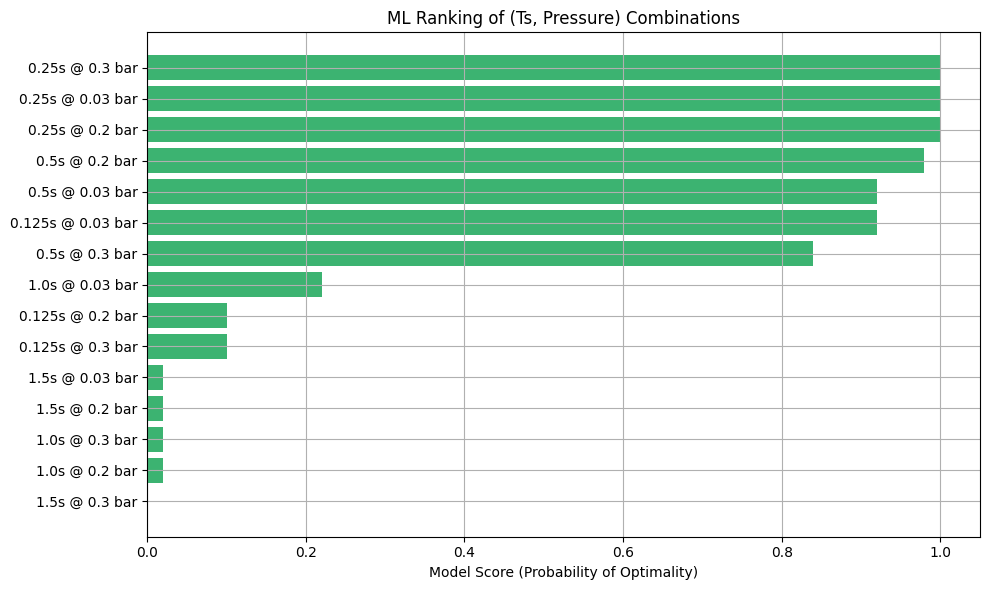

In [22]:
# STEP 9: Plot Scores
plt.figure(figsize=(10, 6))
plt.barh(
    features_df['Ts'].astype(str) + 's @ ' + features_df['Pc'].astype(str) + ' bar',
    features_df['Score'],
    color='mediumseagreen'
  )
plt.xlabel("Model Score (Probability of Optimality)")
plt.title("ML Ranking of (Ts, Pressure) Combinations")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

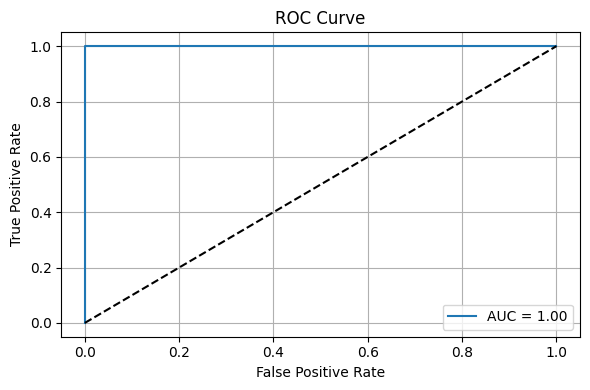

In [23]:
# STEP 10: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

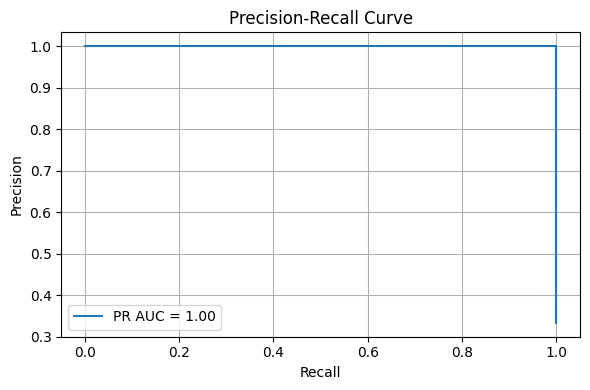

In [24]:
# STEP 11: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# STEP 12: Show Ranked Table
features_df.reset_index(drop=True, inplace=True)
features_df[['Ts', 'Pc', 'MeanFlow', 'StdFlow', 'Range', 'Score', 'Label']]

,Ts,Pc,MeanFlow,StdFlow,Range,Score,Label
0,0.250,0.30,0.373376,0.766822,5.088,1.00,1
1,0.250,0.03,0.307330,0.623544,2.896,1.00,1
2,0.250,0.20,0.600384,1.227532,8.580,1.00,1
3,0.500,0.20,0.876360,2.153584,9.274,0.98,1
4,0.500,0.03,3.925368,1.625889,8.848,0.92,1
5,0.125,0.03,4.594455,0.948267,4.952,0.92,1
6,0.500,0.30,1.612059,2.936634,8.590,0.84,1
7,1.000,0.03,1.231396,3.457711,15.718,0.22,0
8,0.125,0.20,-0.520639,4.599371,14.478,0.10,0
9,0.125,0.30,0.224181,4.857746,15.970,0.10,0
